In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Graph Style set karo
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries ready!")

Libraries ready!


In [2]:
df=pd.read_csv('../data/raw/desert_hydroponic_dataset.csv')
print("Shape:",df.shape)
print("\nColumns:",df.columns.to_list())
df.head()

Shape: (5000, 11)

Columns: ['temperature', 'humidity', 'soil_moisture', 'pH_level', 'light_hours', 'water_given_ml', 'nutrient_level', 'co2_ppm', 'day_number', 'yield_kg', 'water_stress']


,temperature,humidity,soil_moisture,pH_level,light_hours,water_given_ml,nutrient_level,co2_ppm,day_number,yield_kg,water_stress
0,42.490802,21.809066,42.418449,6.499340,11.839986,136.948336,63.814457,887.514105,27.902084,4.943280,0
1,54.014286,24.203070,39.974726,6.993494,7.476096,124.301492,45.929245,431.122774,9.533600,0.413325,1
2,49.639879,35.636422,30.569235,6.625334,8.773118,341.676780,96.449852,889.808273,12.372330,6.423662,1
3,46.973170,20.200132,56.436000,5.666605,11.306245,486.446529,21.897845,471.734885,17.260402,3.918849,1
4,38.120373,36.089491,48.597450,5.871160,9.856715,301.088524,58.785642,968.275391,19.328800,5.886870,0


In [3]:
#Basic Info
print("---Data Types---")
print(df.dtypes)

print("\n----Null Values----")
print(df.isnull().sum())

print("\n----Basic Stats----")
df.describe().round(2)

---Data Types---
temperature       float64
humidity          float64
soil_moisture     float64
pH_level          float64
light_hours       float64
water_given_ml    float64
nutrient_level    float64
co2_ppm           float64
day_number        float64
yield_kg          float64
water_stress        int64
dtype: object

----Null Values----
temperature       0
humidity          0
soil_moisture     0
pH_level          0
light_hours       0
water_given_ml    0
nutrient_level    0
co2_ppm           0
day_number        0
yield_kg          0
water_stress      0
dtype: int64

----Basic Stats----


,temperature,humidity,soil_moisture,pH_level,light_hours,water_given_ml,nutrient_level,co2_ppm,day_number,yield_kg,water_stress
count,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00,5000.00
mean,44.94,24.74,50.08,6.52,10.07,296.53,50.06,797.45,45.86,4.17,0.58
std,5.79,8.57,17.45,0.58,2.31,113.82,28.83,231.74,26.04,2.00,0.49
min,35.00,10.00,20.01,5.50,6.00,100.04,0.00,400.14,1.00,0.10,0.00
25%,39.88,17.41,34.83,6.03,8.07,198.86,24.75,596.97,23.34,2.74,0.00
50%,45.00,24.58,49.77,6.52,10.11,296.39,50.19,798.68,45.22,4.16,1.00
75%,49.96,32.00,65.64,7.00,12.06,392.86,74.82,997.58,68.81,5.57,1.00
max,54.99,39.99,79.99,7.50,14.00,499.89,99.98,1199.41,91.00,9.99,1.00


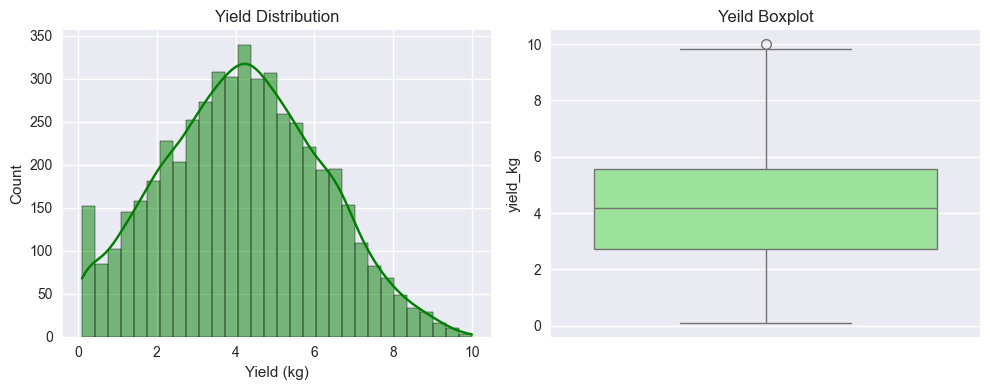

In [4]:
#Yeild Distribution
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
sns.histplot(df['yield_kg'],kde=True,color='green')
plt.title('Yield Distribution')
plt.xlabel('Yield (kg)')

plt.subplot(1,2,2)
sns.boxplot(y=df['yield_kg'],color='lightgreen')
plt.title('Yeild Boxplot')

plt.tight_layout()
plt.savefig('../data/processed/yield_distribution.png')

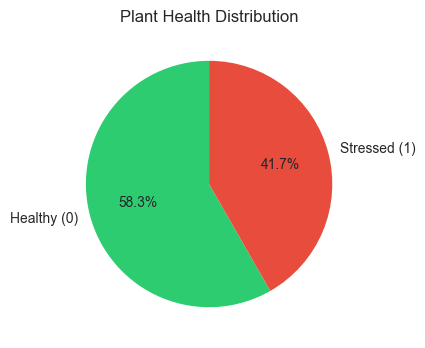

Healthy plants: 2086
Stressed plants: 2914


In [5]:
#Water Stress Count
plt.figure(figsize=(6, 4))

stress_counts = df['water_stress'].value_counts()
labels = ['Healthy (0)', 'Stressed (1)']
colors = ['#2ecc71', '#e74c3c']

plt.pie(stress_counts, labels=labels, colors=colors,autopct='%1.1f%%', startangle=90)
plt.title('Plant Health Distribution')
plt.savefig('../data/processed/stress_distribution.png')
plt.show()

print(f"Healthy plants: {stress_counts[0]}")
print(f"Stressed plants: {stress_counts[1]}")

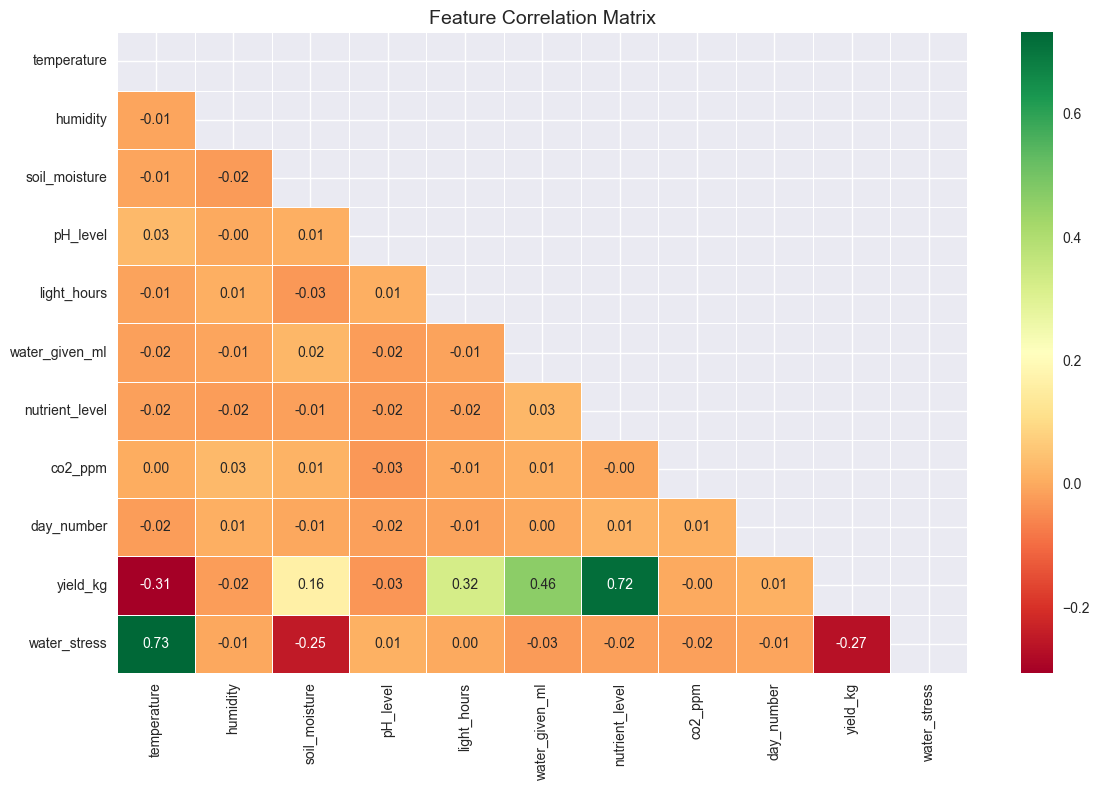

In [6]:
#Corelation Heat map
plt.figure(figsize=(12, 8))

corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, 
            annot=True, 
            fmt='.2f', 
            cmap='RdYlGn',
            mask=mask,
            linewidths=0.5)

plt.title('Feature Correlation Matrix', fontsize=14)
plt.tight_layout()
plt.savefig('../data/processed/correlation_heatmap.png')
plt.show()

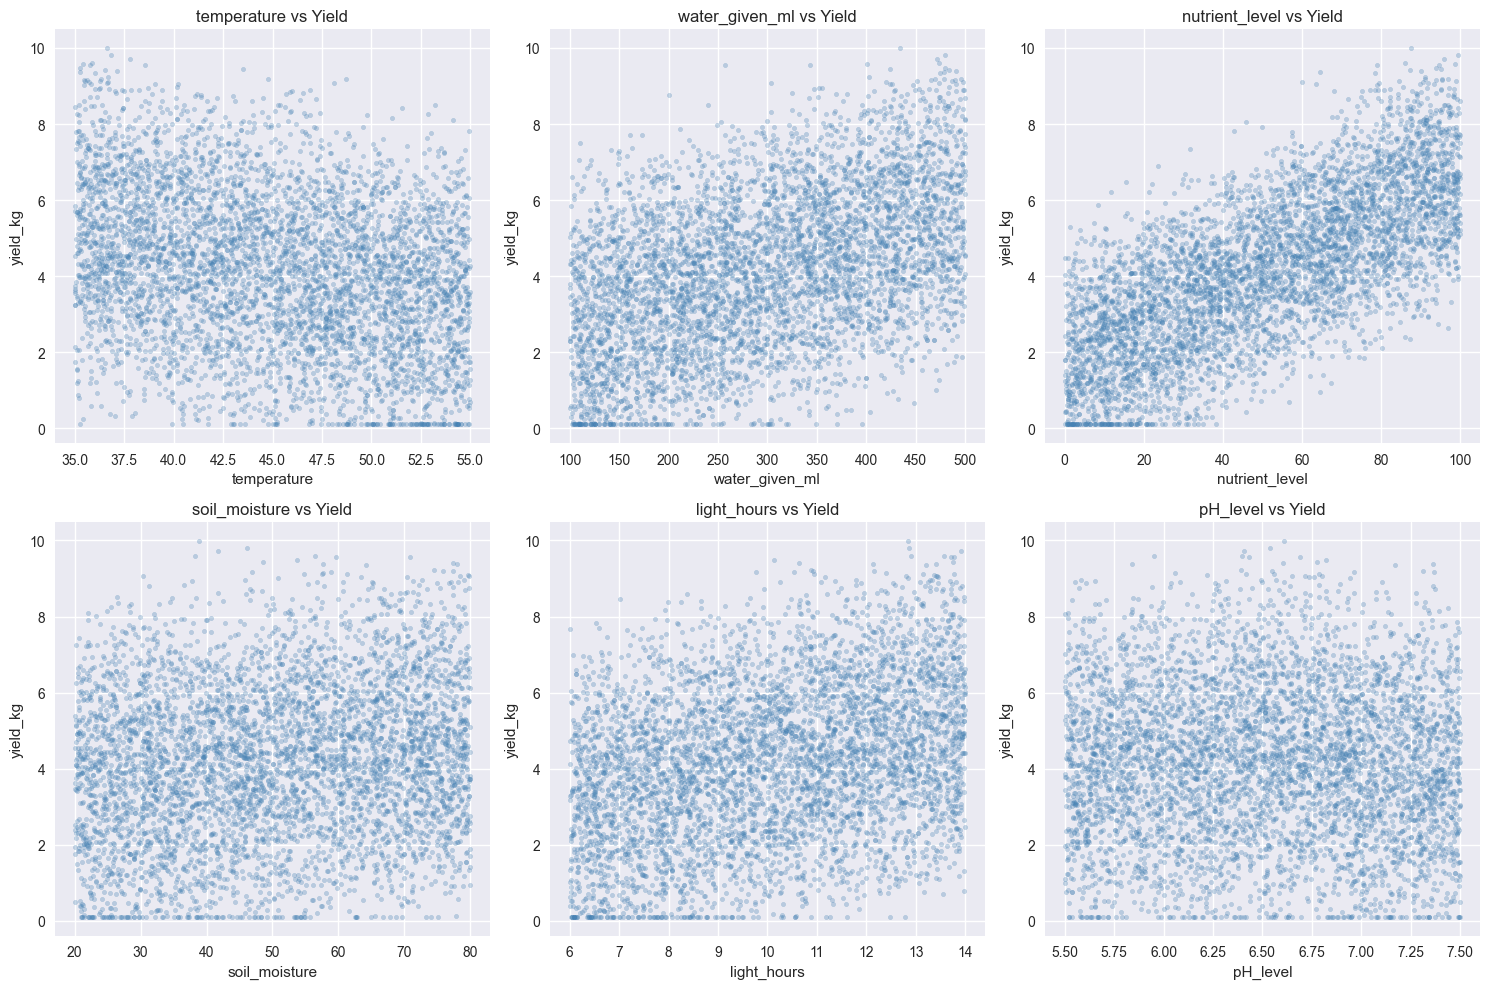

In [7]:
# Top Feature vs Yield
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = ['temperature', 'water_given_ml', 
            'nutrient_level', 'soil_moisture', 
            'light_hours', 'pH_level']

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    axes[row, col].scatter(df[feature], df['yield_kg'], 
                           alpha=0.3, color='steelblue', s=10)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('yield_kg')
    axes[row, col].set_title(f'{feature} vs Yield')

plt.tight_layout()
plt.savefig('../data/processed/features_vs_yield.png')
plt.show()

In [8]:
#EDA Summary
print("=" * 40)
print("EDA SUMMARY - DESERT AGRITECH")
print("=" * 40)
print(f"Total Records    : {len(df)}")
print(f"Total Features   : {df.shape[1] - 2}")
print(f"Target Variables : yield_kg, water_stress")
print(f"Missing Values   : {df.isnull().sum().sum()}")
print(f"Avg Yield        : {df['yield_kg'].mean():.2f} kg")
print(f"Max Yield        : {df['yield_kg'].max():.2f} kg")
print(f"Stressed Plants  : {df['water_stress'].mean()*100:.1f}%")
print("=" * 40)
print("EDA Complete! Ready for Feature Engineering.")

EDA SUMMARY - DESERT AGRITECH
Total Records    : 5000
Total Features   : 9
Target Variables : yield_kg, water_stress
Missing Values   : 0
Avg Yield        : 4.17 kg
Max Yield        : 9.99 kg
Stressed Plants  : 58.3%
EDA Complete! Ready for Feature Engineering.
